<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/Implementasi_Group_K_Fold_RT_IoT2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pilih sumber dataset:
1. Upload manual file CSV
2. Ambil dataset langsung dari UCI
3. Baca file CSV dari path lokal/runtime
Masukkan pilihan (1/2/3): 1

Silakan upload file CSV Anda.


Saving RT_IOT2022_clean_integrity_checked.csv to RT_IOT2022_clean_integrity_checked.csv

File berhasil di-upload: RT_IOT2022_clean_integrity_checked.csv
Ukuran dataset: (117922, 84)

Daftar kolom dataset:
['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg',

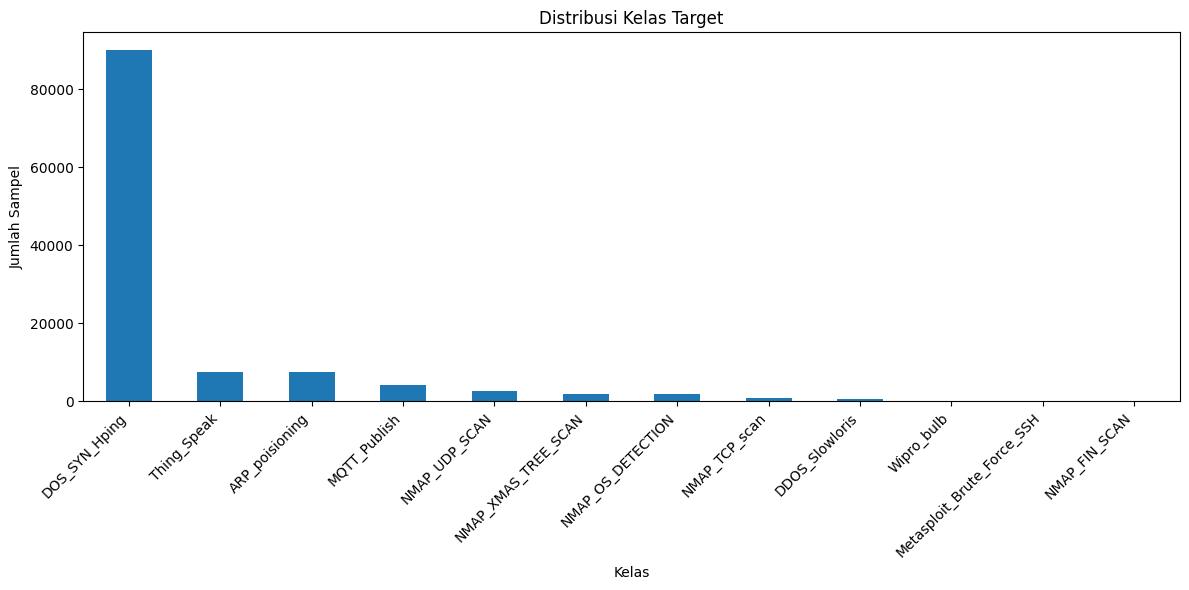


===== INFORMASI PREPROCESSING =====
Jumlah kolom numerik     : 81
Jumlah kolom kategorikal : 2

===== HASIL PER FOLD =====
   fold  train_samples  test_samples  train_unique_groups  test_unique_groups  \
0     1          94337         23585                73100               18253   
1     2          94337         23585                73081               18272   
2     3          94338         23584                73078               18275   
3     4          94338         23584                73077               18276   
4     5          94338         23584                73076               18277   

   group_overlap_count  train_accuracy  test_accuracy  train_f1_macro  \
0                    0        0.999629       0.994615        0.996665   
1                    0        0.999470       0.997795        0.984039   
2                    0        0.999481       0.998262        0.990730   
3                    0        0.999428       0.997965        0.987266   
4                    0  

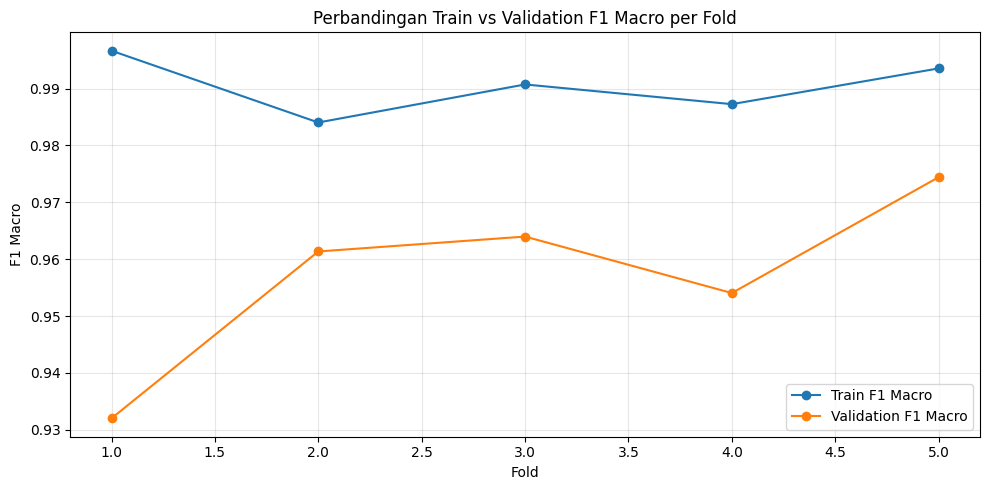

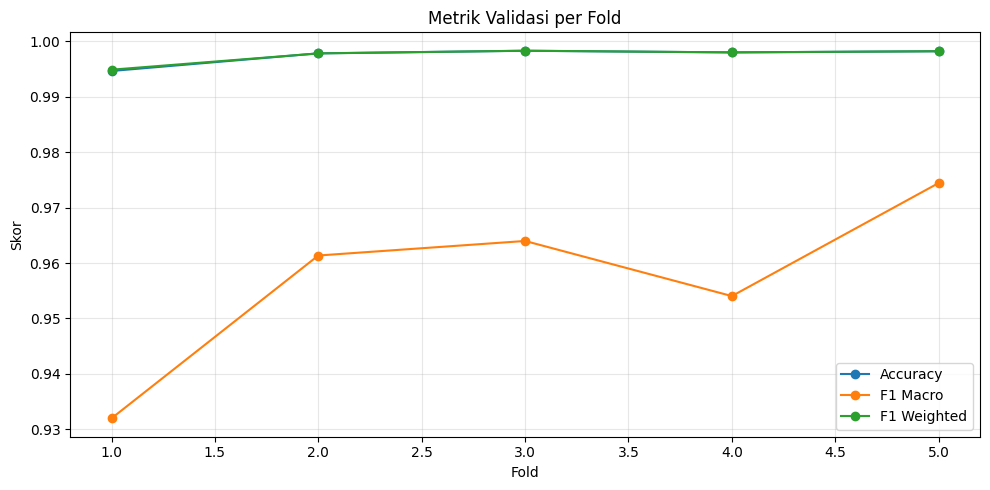

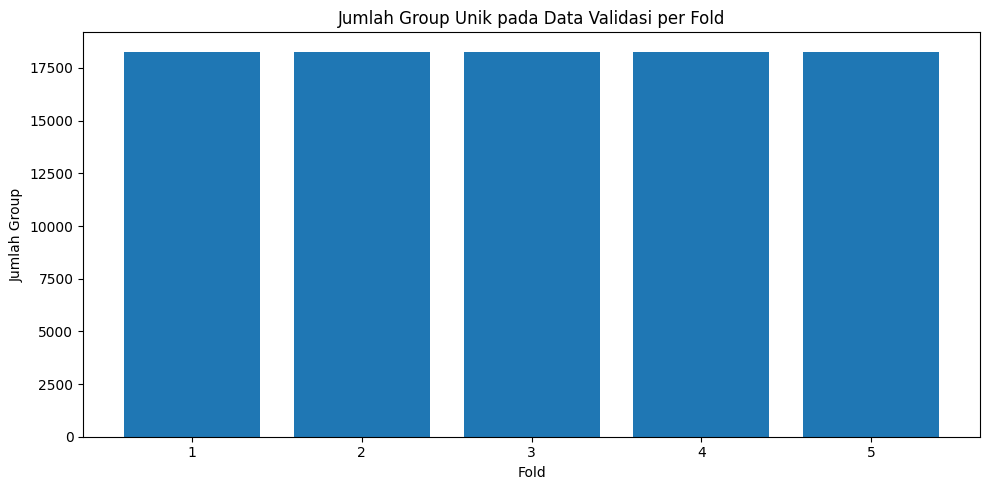

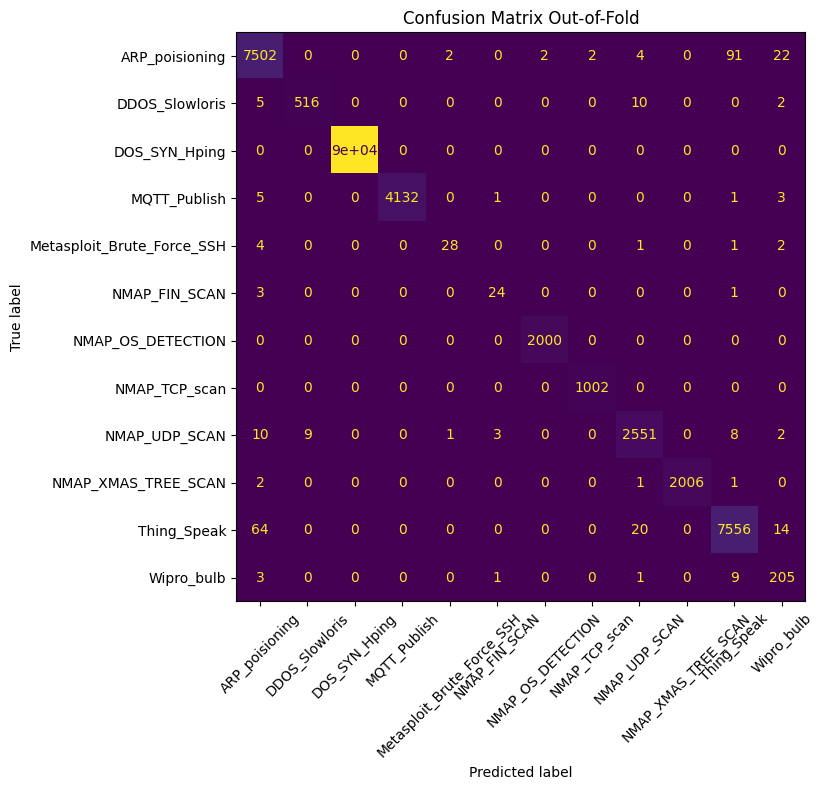


===== TOP 20 FEATURE IMPORTANCE =====
                       feature  importance
80   num__fwd_last_window_size    0.043159
23     num__fwd_URG_flag_count    0.043042
1               num__id.resp_p    0.039081
20     num__fwd_PSH_flag_count    0.032270
52           num__flow_iat.min    0.031941
12    num__fwd_header_size_min    0.031648
38  num__flow_pkts_payload.max    0.031318
30   num__fwd_pkts_payload.avg    0.026975
9       num__flow_pkts_per_sec    0.025969
17    num__flow_FIN_flag_count    0.025896
78   num__fwd_init_window_size    0.025476
39  num__flow_pkts_payload.tot    0.024797
28   num__fwd_pkts_payload.max    0.024736
89           cat__service_mqtt    0.024567
11    num__fwd_header_size_tot    0.022984
40  num__flow_pkts_payload.avg    0.022185
8        num__bwd_pkts_per_sec    0.021268
13    num__fwd_header_size_max    0.021249
68             num__active.min    0.020129
29   num__fwd_pkts_payload.tot    0.019503


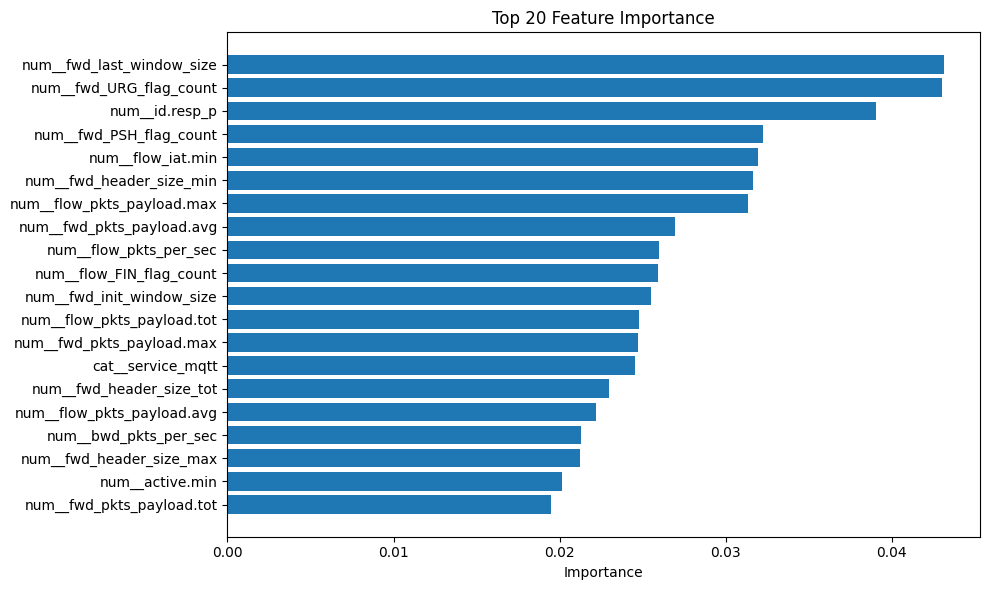


Model berhasil disimpan ke: model_group_kfold_rt_iot2022.pkl
Metadata model berhasil disimpan ke: model_group_kfold_rt_iot2022_metadata.json

Pilih jumlah sampel untuk pengujian deployment sederhana:
1. 3 sampel
2. 5 sampel
Masukkan pilihan (1/2): 1

===== HASIL PENGUJIAN DEPLOYMENT SEDERHANA =====
        id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
41661       24331         21   tcp       -       0.000001             1   
13948       42518        443   udp       -      51.527887           490   
109803      20185         21   tcp       -       0.000000             1   

        bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  fwd_pkts_per_sec  \
41661              1                  1                  0      1.048576e+06   
13948            355                490                355      9.509414e+00   
109803             0                  1                  0      0.000000e+00   

        ...    idle.max     idle.tot     idle.avg     idle.std  \
41661   ...

In [1]:
# ============================================================
# JUDUL PROGRAM
# Implementasi Teknik Group K-Fold Cross-Validation
# pada Dataset RT-IoT2022 dengan Pengendalian Data Leakage,
# Evaluasi Per Fold, Penyimpanan Model, dan Pengujian Deployment
# ============================================================

# ------------------------------------------------------------
# DESKRIPSI SINGKAT
# ------------------------------------------------------------
# Program ini merupakan adaptasi dari notebook sumber berbasis K-Fold
# menjadi Group K-Fold Cross-Validation.
#
# Tujuan utamanya adalah menjaga agar sampel yang berasal dari grup yang
# sama tidak terpecah ke data latih dan data validasi pada fold berbeda.
# Dengan demikian, evaluasi model menjadi lebih ketat dan risiko data
# leakage antar-fold dapat dikurangi.
#
# Program mendukung tiga cara pemuatan data:
# 1. Upload manual file CSV
# 2. Mengambil dataset langsung dari UCI
# 3. Membaca file CSV dari path lokal/runtime
#
# Program ini mencakup:
# - validasi kualitas data,
# - identifikasi kolom target,
# - pembentukan group label secara manual atau otomatis,
# - preprocessing numerik dan kategorikal,
# - evaluasi model dengan Group K-Fold Cross-Validation,
# - diagnosis underfitting dan overfitting,
# - visualisasi tabel dan grafik,
# - penyimpanan model final,
# - pengujian deployment sederhana menggunakan 3 atau 5 sampel data.
# ============================================================

# ------------------------------------------------------------
# INSTALASI PUSTAKA
# ------------------------------------------------------------
# Jalankan baris di bawah ini bila Anda menggunakan Google Colab.
# !pip -q install ucimlrepo joblib

# ------------------------------------------------------------
# IMPORT PUSTAKA
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# BAGIAN 1. FUNGSI PEMUATAN DATASET
# ------------------------------------------------------------
def load_dataset_flexible():
    """
    Fungsi ini menyediakan tiga alternatif sumber dataset.
    Tujuannya adalah meningkatkan fleksibilitas penelitian dan
    mengurangi ketergantungan pada satu sumber data.
    """
    print("Pilih sumber dataset:")
    print("1. Upload manual file CSV")
    print("2. Ambil dataset langsung dari UCI")
    print("3. Baca file CSV dari path lokal/runtime")

    source_choice = input("Masukkan pilihan (1/2/3): ").strip()

    if source_choice == "1":
        print("\nSilakan upload file CSV Anda.")
        from google.colab import files
        uploaded = files.upload()

        if len(uploaded) == 0:
            raise ValueError("Tidak ada file yang di-upload.")

        uploaded_filename = list(uploaded.keys())[0]
        df = pd.read_csv(uploaded_filename)

        if df.empty:
            raise ValueError("Dataset hasil upload kosong.")

        print(f"\nFile berhasil di-upload: {uploaded_filename}")
        print(f"Ukuran dataset: {df.shape}")
        return df, "upload_manual", uploaded_filename

    elif source_choice == "2":
        print("\nMengambil dataset dari UCI...")
        from ucimlrepo import fetch_ucirepo

        rt_iot = fetch_ucirepo(id=942)
        X = rt_iot.data.features.copy()
        y_raw = rt_iot.data.targets.copy()

        if X is None or len(X) == 0:
            raise ValueError("Fitur dari UCI tidak berhasil dimuat atau kosong.")

        if isinstance(y_raw, pd.DataFrame):
            if y_raw.shape[1] >= 1:
                y = y_raw.iloc[:, 0].copy()
            else:
                raise ValueError("Kolom target dari UCI tidak ditemukan.")
        else:
            y = pd.Series(y_raw).copy()

        if len(y) != len(X):
            raise ValueError("Jumlah fitur dan target dari UCI tidak sama.")

        df = X.copy()
        df["Attack_type"] = y.values

        print("Dataset berhasil diambil dari UCI.")
        print(f"Ukuran dataset: {df.shape}")
        return df, "uci_repository", "RT-IoT2022 (ID 942)"

    elif source_choice == "3":
        csv_path = input("Masukkan path file CSV: ").strip()

        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"File tidak ditemukan: {csv_path}")

        df = pd.read_csv(csv_path)

        if df.empty:
            raise ValueError("Dataset dari path lokal kosong.")

        print(f"\nDataset berhasil dibaca dari: {csv_path}")
        print(f"Ukuran dataset: {df.shape}")
        return df, "local_path", csv_path

    else:
        raise ValueError("Pilihan tidak valid. Harus 1, 2, atau 3.")


# ------------------------------------------------------------
# BAGIAN 2. FUNGSI IDENTIFIKASI TARGET
# ------------------------------------------------------------
def identify_target_column(df):
    """
    Fungsi ini mengidentifikasi kolom target secara fleksibel.
    Program akan mencoba mendeteksi kandidat target umum terlebih dahulu.
    Jika tidak sesuai, pengguna dapat menentukan secara manual.
    """
    if df is None or df.empty:
        raise ValueError("DataFrame kosong sehingga kolom target tidak dapat diidentifikasi.")

    print("\nDaftar kolom dataset:")
    print(df.columns.tolist())

    kandidat_target = [
        "label", "Label", "target", "Target", "class", "Class",
        "Attack_type", "attack_type", "Attack", "attack"
    ]

    detected = [col for col in kandidat_target if col in df.columns]

    if len(detected) > 0:
        print(f"\nKolom target yang terdeteksi otomatis: {detected[0]}")
        use_auto = input("Gunakan kolom ini sebagai target? (y/n): ").strip().lower()

        if use_auto == "y":
            return detected[0]

    target_col = input("Masukkan nama kolom target secara manual: ").strip()

    if target_col not in df.columns:
        raise ValueError(f"Kolom target '{target_col}' tidak ditemukan dalam dataset.")

    return target_col


# ------------------------------------------------------------
# BAGIAN 3. FUNGSI IDENTIFIKASI DAN PEMBENTUKAN GROUP
# ------------------------------------------------------------
def build_group_labels(df, target_col, n_splits=5):
    """
    Fungsi ini membentuk label group untuk Group K-Fold.

    Strategi yang disediakan:
    1. Kolom grup tunggal yang sudah ada di dataset.
    2. Grup komposit otomatis dari beberapa kolom yang relevan.

    Untuk RT-IoT2022, grup komposit direkomendasikan karena struktur data
    umumnya lebih representatif bila dibentuk dari kombinasi atribut lalu lintas.
    """
    if df is None or df.empty:
        raise ValueError("DataFrame kosong sehingga group label tidak dapat dibentuk.")

    candidate_auto_cols = [
        "id.orig_p", "id.resp_p", "proto", "service"
    ]
    available_auto_cols = [col for col in candidate_auto_cols if col in df.columns]

    candidate_manual_cols = [
        col for col in df.columns
        if col != target_col and df[col].nunique(dropna=False) >= n_splits
    ]

    print("\n===== KONFIGURASI GROUP =====")
    print("Pilih cara membentuk group untuk Group K-Fold:")
    print("1. Gunakan grup komposit otomatis (direkomendasikan untuk RT-IoT2022)")
    print("2. Gunakan satu kolom grup secara manual")

    if available_auto_cols:
        print(f"Kolom kandidat grup komposit otomatis: {available_auto_cols}")
    else:
        print("Kolom kandidat grup komposit otomatis tidak lengkap/tersedia.")

    choice = input("Masukkan pilihan (1/2): ").strip()

    if choice == "1":
        if len(available_auto_cols) == 0:
            raise ValueError(
                "Grup komposit otomatis tidak dapat dibentuk karena kolom kandidat tidak tersedia."
            )

        groups = (
            df[available_auto_cols]
            .astype(str)
            .fillna("MISSING_GROUP_VALUE")
            .agg(" | ".join, axis=1)
        )
        group_info = {
            "group_mode": "auto_composite",
            "group_columns": available_auto_cols,
            "group_name": "composite_group"
        }

    elif choice == "2":
        print("\nKolom yang layak dipakai sebagai grup (jumlah grup unik >= n_splits):")
        print(candidate_manual_cols)
        group_col = input("Masukkan nama kolom grup: ").strip()

        if group_col not in df.columns:
            raise ValueError(f"Kolom grup '{group_col}' tidak ditemukan dalam dataset.")

        groups = df[group_col].astype(str).fillna("MISSING_GROUP_VALUE")
        group_info = {
            "group_mode": "single_column",
            "group_columns": [group_col],
            "group_name": group_col
        }

    else:
        raise ValueError("Pilihan group tidak valid. Harus 1 atau 2.")

    n_unique_groups = groups.nunique(dropna=False)
    if n_unique_groups < n_splits:
        raise ValueError(
            f"Jumlah grup unik ({n_unique_groups}) lebih kecil dari jumlah fold ({n_splits})."
        )

    return groups.reset_index(drop=True), group_info


# ------------------------------------------------------------
# BAGIAN 4. FUNGSI PEMBANGUN PREPROCESSOR
# ------------------------------------------------------------
def build_preprocessor(X):
    """
    Fungsi ini membangun preprocessing yang aman untuk kolom numerik
    dan kategorikal. Bila salah satu tipe kolom tidak tersedia,
    program tetap berjalan tanpa error.
    """
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

    transformers = []

    if len(numeric_cols) > 0:
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        transformers.append(("num", numeric_transformer, numeric_cols))

    if len(categorical_cols) > 0:
        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
        transformers.append(("cat", categorical_transformer, categorical_cols))

    if len(transformers) == 0:
        raise ValueError("Tidak ada kolom numerik maupun kategorikal yang dapat diproses.")

    preprocessor = ColumnTransformer(transformers=transformers)
    return preprocessor, numeric_cols, categorical_cols


# ------------------------------------------------------------
# BAGIAN 5. FUNGSI EVALUASI GROUP K-FOLD
# ------------------------------------------------------------
def evaluate_group_kfold_model(
    X,
    y_encoded,
    groups,
    preprocessor,
    class_names,
    model_params,
    n_splits=5
):
    """
    Fungsi ini mengevaluasi model dengan Group K-Fold Cross-Validation.
    Hasil evaluasi meliputi skor train dan validation, ringkasan statistik,
    classification report, confusion matrix, serta diagnostik kebocoran grup.
    """
    if len(X) != len(y_encoded):
        raise ValueError("Jumlah baris fitur dan target tidak sama.")

    if len(X) != len(groups):
        raise ValueError("Jumlah baris fitur dan groups tidak sama.")

    if len(np.unique(y_encoded)) < 2:
        raise ValueError("Target hanya memiliki satu kelas. Model klasifikasi tidak dapat dilatih.")

    if len(X) < n_splits:
        raise ValueError(f"Jumlah data ({len(X)}) lebih kecil dari jumlah fold ({n_splits}).")

    unique_group_count = pd.Series(groups).nunique(dropna=False)
    if unique_group_count < n_splits:
        raise ValueError(
            f"Jumlah group unik ({unique_group_count}) lebih kecil dari jumlah fold ({n_splits})."
        )

    gkf = GroupKFold(n_splits=n_splits)

    fold_results = []
    oof_true = []
    oof_pred = []

    groups_series = pd.Series(groups).reset_index(drop=True)

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y_encoded, groups=groups_series), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

        train_groups = groups_series.iloc[train_idx]
        test_groups = groups_series.iloc[test_idx]

        train_group_set = set(train_groups.tolist())
        test_group_set = set(test_groups.tolist())
        overlap_groups = train_group_set.intersection(test_group_set)

        pipe = Pipeline(steps=[
            ("prep", preprocessor),
            ("clf", RandomForestClassifier(**model_params))
        ])

        pipe.fit(X_train, y_train)

        pred_train = pipe.predict(X_train)
        pred_test = pipe.predict(X_test)

        oof_true.extend(y_test)
        oof_pred.extend(pred_test)

        row = {
            "fold": fold,
            "train_samples": len(train_idx),
            "test_samples": len(test_idx),
            "train_unique_groups": train_groups.nunique(dropna=False),
            "test_unique_groups": test_groups.nunique(dropna=False),
            "group_overlap_count": len(overlap_groups),
            "train_accuracy": accuracy_score(y_train, pred_train),
            "test_accuracy": accuracy_score(y_test, pred_test),
            "train_f1_macro": f1_score(y_train, pred_train, average="macro", zero_division=0),
            "test_f1_macro": f1_score(y_test, pred_test, average="macro", zero_division=0),
            "train_f1_weighted": f1_score(y_train, pred_train, average="weighted", zero_division=0),
            "test_f1_weighted": f1_score(y_test, pred_test, average="weighted", zero_division=0),
            "train_precision_macro": precision_score(y_train, pred_train, average="macro", zero_division=0),
            "test_precision_macro": precision_score(y_test, pred_test, average="macro", zero_division=0),
            "train_recall_macro": recall_score(y_train, pred_train, average="macro", zero_division=0),
            "test_recall_macro": recall_score(y_test, pred_test, average="macro", zero_division=0),
        }
        fold_results.append(row)

    fold_df = pd.DataFrame(fold_results)

    summary_df = fold_df.drop(columns=["fold"]).agg(["mean", "std"]).T.reset_index()
    summary_df.columns = ["metric", "mean", "std"]

    oof_true = np.array(oof_true)
    oof_pred = np.array(oof_pred)

    report_df = pd.DataFrame(
        classification_report(
            oof_true,
            oof_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )
    ).T

    cm = confusion_matrix(oof_true, oof_pred)

    avg_train_f1 = fold_df["train_f1_macro"].mean()
    avg_test_f1 = fold_df["test_f1_macro"].mean()
    generalization_gap = avg_train_f1 - avg_test_f1
    leakage_indicator = int(fold_df["group_overlap_count"].sum())

    if generalization_gap > 0.05 and avg_train_f1 > avg_test_f1:
        fit_status = "Indikasi overfitting"
    elif avg_train_f1 < 0.75 and avg_test_f1 < 0.75:
        fit_status = "Indikasi underfitting"
    else:
        fit_status = "Relatif seimbang"

    diagnostics = {
        "avg_train_f1_macro": avg_train_f1,
        "avg_test_f1_macro": avg_test_f1,
        "generalization_gap": generalization_gap,
        "fit_status": fit_status,
        "total_group_overlap": leakage_indicator,
        "group_leakage_status": "Tidak terdeteksi" if leakage_indicator == 0 else "Perlu diperiksa"
    }

    return fold_df, summary_df, report_df, cm, diagnostics


# ------------------------------------------------------------
# BAGIAN 6. FUNGSI PENYIMPANAN MODEL
# ------------------------------------------------------------
def save_model(
    model,
    label_encoder,
    target_col,
    feature_columns,
    group_info,
    model_path="model_group_kfold_rt_iot2022.pkl",
    meta_path="model_group_kfold_rt_iot2022_metadata.json"
):
    """
    Fungsi ini menyimpan model final beserta metadata penting
    agar model dapat digunakan kembali pada tahap deployment.
    """
    joblib.dump(model, model_path)

    metadata = {
        "target_column": target_col,
        "feature_columns": feature_columns,
        "class_labels": list(label_encoder.classes_),
        "group_mode": group_info.get("group_mode"),
        "group_columns": group_info.get("group_columns"),
        "group_name": group_info.get("group_name")
    }

    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=4)

    print(f"\nModel berhasil disimpan ke: {model_path}")
    print(f"Metadata model berhasil disimpan ke: {meta_path}")


# ------------------------------------------------------------
# BAGIAN 7. FUNGSI PENGUJIAN DEPLOYMENT SEDERHANA
# ------------------------------------------------------------
def simple_deployment_test(model, X_source, y_source, label_encoder, n_samples=5, random_state=42):
    """
    Fungsi ini melakukan simulasi pengujian deployment sederhana
    menggunakan 3 atau 5 sampel data untuk melihat apakah model
    dapat melakukan prediksi secara operasional.
    """
    if n_samples not in [3, 5]:
        raise ValueError("Jumlah sampel pengujian deployment sederhana hanya boleh 3 atau 5.")

    if len(X_source) < n_samples:
        raise ValueError("Jumlah data tidak cukup untuk pengujian deployment sederhana.")

    sample_df = X_source.sample(n=n_samples, random_state=random_state).copy()
    sample_index = sample_df.index

    y_true = y_source.loc[sample_index].astype(str).values
    y_pred_encoded = model.predict(sample_df)
    y_pred = label_encoder.inverse_transform(y_pred_encoded)

    result_df = sample_df.copy()
    result_df["Aktual"] = y_true
    result_df["Prediksi"] = y_pred
    result_df["Kesesuaian"] = np.where(result_df["Aktual"] == result_df["Prediksi"], "Benar", "Salah")

    success_rate = (result_df["Kesesuaian"] == "Benar").mean()

    return result_df, success_rate


# ------------------------------------------------------------
# BAGIAN 8. MEMUAT DATASET DAN MENENTUKAN TARGET
# ------------------------------------------------------------
df, source_type, source_info = load_dataset_flexible()
target_col = identify_target_column(df)

print("\n===== INFORMASI SUMBER DATA =====")
print("Sumber data :", source_type)
print("Info sumber :", source_info)
print("Kolom target:", target_col)

if target_col not in df.columns:
    raise ValueError("Kolom target tidak tersedia di dalam dataset.")

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

if X.empty:
    raise ValueError("Data fitur kosong setelah kolom target dipisahkan.")

if y.empty:
    raise ValueError("Data target kosong.")

print("\n===== UKURAN DATA =====")
print("Fitur :", X.shape)
print("Target:", y.shape)


# ------------------------------------------------------------
# BAGIAN 9. VALIDASI AWAL DATA
# ------------------------------------------------------------
print("\n===== VALIDASI AWAL =====")
print("Jumlah missing values pada fitur :", int(X.isna().sum().sum()))
print("Jumlah missing values pada target:", int(y.isna().sum()))

valid_idx = y.notna()
X = X.loc[valid_idx].reset_index(drop=True)
y = y.loc[valid_idx].reset_index(drop=True)
df_clean = pd.concat([X, y.rename(target_col)], axis=1)

if len(X) == 0 or len(y) == 0:
    raise ValueError("Semua data terhapus setelah pembersihan target kosong.")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y.astype(str))
class_names = label_encoder.classes_

if len(class_names) < 2:
    raise ValueError("Kelas target kurang dari 2. Klasifikasi tidak dapat dijalankan.")

class_dist = pd.Series(y.astype(str)).value_counts().sort_values(ascending=False)
imbalance_ratio = class_dist.iloc[0] / class_dist.iloc[-1] if len(class_dist) > 1 else 1.0

print("\n===== DISTRIBUSI KELAS =====")
print(class_dist)
print(f"\nImbalance ratio (mayoritas/minoritas): {imbalance_ratio:.4f}")


# ------------------------------------------------------------
# BAGIAN 10. PEMBENTUKAN GROUP LABEL
# ------------------------------------------------------------
groups, group_info = build_group_labels(df_clean, target_col=target_col, n_splits=5)

print("\n===== INFORMASI GROUP =====")
print("Mode group      :", group_info["group_mode"])
print("Kolom group     :", group_info["group_columns"])
print("Nama group      :", group_info["group_name"])
print("Jumlah group unik:", groups.nunique(dropna=False))
print("Contoh 5 group pertama:")
print(groups.head())


# ------------------------------------------------------------
# BAGIAN 11. VISUALISASI DATA AWAL
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
class_dist.plot(kind="bar")
plt.title("Distribusi Kelas Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# BAGIAN 12. PREPROCESSING
# ------------------------------------------------------------
preprocessor, numeric_cols, categorical_cols = build_preprocessor(X)

print("\n===== INFORMASI PREPROCESSING =====")
print("Jumlah kolom numerik     :", len(numeric_cols))
print("Jumlah kolom kategorikal :", len(categorical_cols))


# ------------------------------------------------------------
# BAGIAN 13. KONFIGURASI MODEL
# ------------------------------------------------------------
model_params = {
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_split": 6,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "class_weight": "balanced_subsample",
    "random_state": 42,
    "n_jobs": -1
}


# ------------------------------------------------------------
# BAGIAN 14. EVALUASI DENGAN GROUP K-FOLD CROSS-VALIDATION
# ------------------------------------------------------------
fold_df, summary_df, report_df, cm, diagnostics = evaluate_group_kfold_model(
    X=X,
    y_encoded=y_encoded,
    groups=groups,
    preprocessor=preprocessor,
    class_names=class_names,
    model_params=model_params,
    n_splits=5
)


# ------------------------------------------------------------
# BAGIAN 15. OUTPUT TABEL HASIL
# ------------------------------------------------------------
print("\n===== HASIL PER FOLD =====")
print(fold_df)

print("\n===== RINGKASAN HASIL GROUP K-FOLD =====")
print(summary_df)

print("\n===== CLASSIFICATION REPORT (OUT-OF-FOLD) =====")
print(report_df)

print("\n===== DIAGNOSTIK MODEL =====")
for k, v in diagnostics.items():
    print(f"{k}: {v}")


# ------------------------------------------------------------
# BAGIAN 16. VISUALISASI HASIL EVALUASI
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(fold_df["fold"], fold_df["train_f1_macro"], marker="o", label="Train F1 Macro")
plt.plot(fold_df["fold"], fold_df["test_f1_macro"], marker="o", label="Validation F1 Macro")
plt.title("Perbandingan Train vs Validation F1 Macro per Fold")
plt.xlabel("Fold")
plt.ylabel("F1 Macro")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(fold_df["fold"], fold_df["test_accuracy"], marker="o", label="Accuracy")
plt.plot(fold_df["fold"], fold_df["test_f1_macro"], marker="o", label="F1 Macro")
plt.plot(fold_df["fold"], fold_df["test_f1_weighted"], marker="o", label="F1 Weighted")
plt.title("Metrik Validasi per Fold")
plt.xlabel("Fold")
plt.ylabel("Skor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(fold_df["fold"], fold_df["test_unique_groups"])
plt.title("Jumlah Group Unik pada Data Validasi per Fold")
plt.xlabel("Fold")
plt.ylabel("Jumlah Group")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix Out-of-Fold")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# BAGIAN 17. PELATIHAN MODEL FINAL PADA SELURUH DATA
# ------------------------------------------------------------
final_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(**model_params))
])

final_model.fit(X, y_encoded)


# ------------------------------------------------------------
# BAGIAN 18. FEATURE IMPORTANCE
# ------------------------------------------------------------
feature_names = final_model.named_steps["prep"].get_feature_names_out()
importances = final_model.named_steps["clf"].feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n===== TOP 20 FEATURE IMPORTANCE =====")
print(feat_imp_df.head(20))

plt.figure(figsize=(10, 6))
top20 = feat_imp_df.head(20).sort_values("importance")
plt.barh(top20["feature"], top20["importance"])
plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# BAGIAN 19. SIMPAN MODEL
# ------------------------------------------------------------
save_model(
    model=final_model,
    label_encoder=label_encoder,
    target_col=target_col,
    feature_columns=X.columns.tolist(),
    group_info=group_info,
    model_path="model_group_kfold_rt_iot2022.pkl",
    meta_path="model_group_kfold_rt_iot2022_metadata.json"
)


# ------------------------------------------------------------
# BAGIAN 20. PENGUJIAN DEPLOYMENT SEDERHANA
# ------------------------------------------------------------
print("\nPilih jumlah sampel untuk pengujian deployment sederhana:")
print("1. 3 sampel")
print("2. 5 sampel")
deployment_choice = input("Masukkan pilihan (1/2): ").strip()

if deployment_choice == "1":
    n_test_samples = 3
elif deployment_choice == "2":
    n_test_samples = 5
else:
    raise ValueError("Pilihan pengujian deployment tidak valid.")

deploy_result_df, deploy_success_rate = simple_deployment_test(
    model=final_model,
    X_source=X,
    y_source=y,
    label_encoder=label_encoder,
    n_samples=n_test_samples,
    random_state=42
)

print("\n===== HASIL PENGUJIAN DEPLOYMENT SEDERHANA =====")
print(deploy_result_df)
print(f"\nTingkat keberhasilan prediksi: {deploy_success_rate:.2%}")


# ------------------------------------------------------------
# BAGIAN 21. INTERPRETASI HASIL
# ------------------------------------------------------------
print("\n===== INTERPRETASI SINGKAT =====")
print(
    "Group K-Fold digunakan untuk memastikan bahwa sampel dari grup yang sama "
    "tidak muncul bersamaan pada data latih dan data validasi. "
    "Dengan demikian, evaluasi model menjadi lebih ketat terhadap potensi data leakage."
)
print(
    "Namun, perlu diingat bahwa Group K-Fold tidak otomatis menjaga proporsi kelas. "
    "Bila penelitian Anda menuntut kontrol yang lebih kuat terhadap imbalance dan group sekaligus, "
    "pendekatan lanjutan yang dapat dipertimbangkan adalah StratifiedGroupKFold."
)